In [4]:
import pymannkendall as mk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
np.random.seed(42)

n = 30
time = pd.date_range(start="1995-01-01", periods=n, freq="YS")  # yearly, start of year

trend = np.linspace(0, 20, n)                     # linear upward trend
cycle = 3 * np.sin(np.linspace(0, 4*np.pi, n))    # slow multi-year cycle
noise = np.random.normal(0, 2, n)

value = 10 + trend + cycle + noise

df = pd.DataFrame({"time": time, "value": value})

In [6]:
def bootstrap_theilsen_yuewang(df, n_boot=1000, value_col="value", random_state=None):
    """
    Bootstrap the raw values (iid resampling with replacement) and compute
    the Yue-Wang modified Mann-Kendall trend/slope on each resample.
    """
    rng = np.random.default_rng(random_state)
    y = df[value_col].to_numpy()
    n = len(y)

    results = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_sample = y[idx]
        res = mk.yue_wang_modification_test(y_sample)
        results.append(res)

    return pd.DataFrame(results, columns=["trend", "h", "p", "z", "Tau", "s", "var_s", "slope", "intercept"])

boot_df = bootstrap_theilsen_yuewang(df, n_boot=1000, random_state=42)

In [9]:
def bootstrap_theilsen_yuewang(df, n_boot=1000, time_col="time", value_col="value",
                                block=False, lag=None, random_state=None):
    """
    Bootstrap the Theil-Sen slope via the Yue-Wang modified Mann-Kendall
    test, using a RESIDUAL bootstrap so the trend structure is preserved
    (resampling raw values directly destroys the trend, since the slope
    depends on value-vs-time order).

    Steps per iteration:
      1. Fit Theil-Sen trend on original data -> slope0, intercept0
      2. residuals = y - (slope0 * t + intercept0)
      3. Resample residuals (iid, or moving-block to keep autocorrelation)
      4. y_boot = fitted trend + resampled residuals
      5. Recompute Yue-Wang MK slope on y_boot
    """
    rng = np.random.default_rng(random_state)
    t_numeric = (df[time_col] - df[time_col].iloc[0]).dt.days.to_numpy() / 365.25
    y = df[value_col].to_numpy()
    n = len(y)

    base = mk.yue_wang_modification_test(y, lag=lag)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * t_numeric + intercept0
    residuals = y - fitted

    if block:
        block_len = max(1, int(np.sqrt(n)))
        n_blocks = int(np.ceil(n / block_len))

    results = []
    for _ in range(n_boot):
        if block:
            starts = rng.integers(0, n - block_len + 1, size=n_blocks)
            idx = np.concatenate([np.arange(s, s + block_len) for s in starts])[:n]
        else:
            idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]

        res = mk.yue_wang_modification_test(y_boot, lag=lag)
        results.append(res)
    boot_df = pd.DataFrame(results, columns=["trend", "h", "p", "z", "Tau", "s", "var_s", "slope", "intercept"])
    return boot_df, slope0, intercept0

In [10]:
def plot_trend_with_uncertainty(df, boot_df, slope0, intercept0,
                                 time_col="time", value_col="value",
                                 ci=95, save_path=None):
    """
    Plots the observed series, the true Theil-Sen trend line, and a
    bootstrap uncertainty band (percentile CI across bootstrapped
    slope/intercept pairs, evaluated at each real time point).
    """
    t_numeric = (df[time_col] - df[time_col].iloc[0]).dt.days.to_numpy() / 365.25
    trend_line = slope0 * t_numeric + intercept0

    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_df["slope"].to_numpy()[:, None] * t_numeric[None, :] + boot_df["intercept"].to_numpy()[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df[time_col], df[value_col], color="#2c3e50", s=25, alpha=0.7,
               label="Observed values", zorder=3)
    ax.plot(df[time_col], trend_line, color="#e74c3c", linewidth=2,
            label=f"Theil-Sen trend (slope={slope0:.3f}/yr)", zorder=2)
    ax.fill_between(df[time_col], lower, upper, color="#e74c3c", alpha=0.15,
                     label=f"{ci}% bootstrap uncertainty band", zorder=1)

    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    ax.set_title("Timeseries with Yue-Wang Theil-Sen Trend and Bootstrapped Uncertainty Band")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

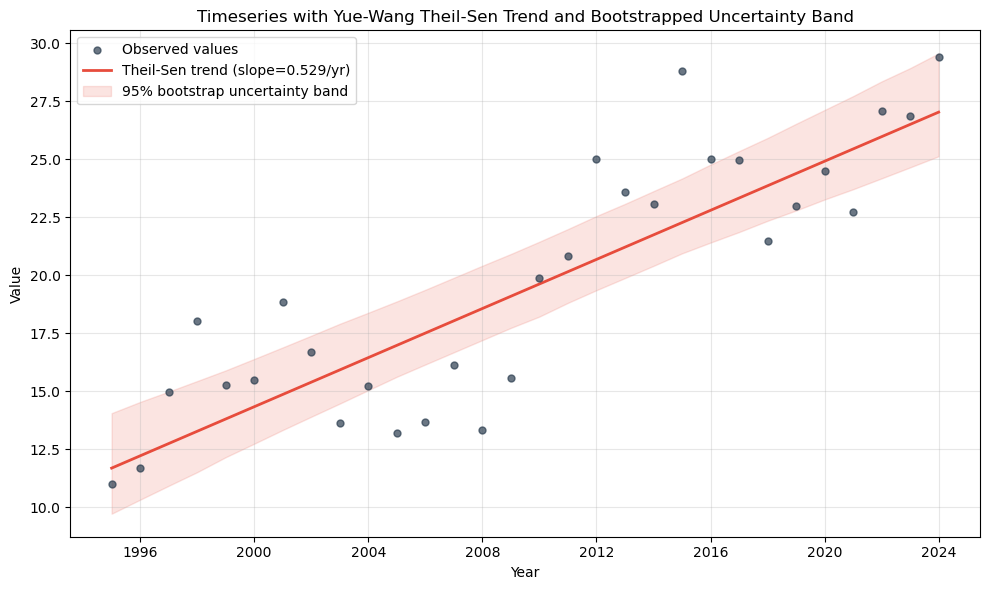

In [11]:
boot_df, slope0, intercept0 = bootstrap_theilsen_yuewang(df, n_boot=1000, random_state=42)
plot_trend_with_uncertainty(df, boot_df, slope0, intercept0, ci=95)

<Axes: >

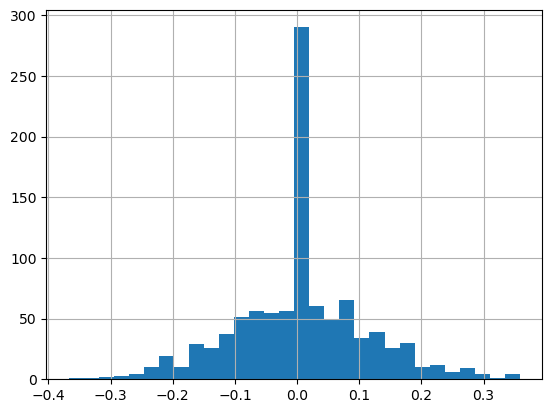

In [7]:
boot_df["slope"].hist(bins=30)